<a href="https://colab.research.google.com/github/ivangacha89/Ventas-Python/blob/main/Proyecto_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Intermedio Python

## Exploracion inicial de datos

In [1]:
# Importar librerias
import pandas as pd
import numpy as np

In [2]:
# Carga del archivo excel
df = pd.read_excel("/content/sample_data/Datos_Proyecto_Intermedio.xlsx")

In [3]:
# Copia de respaldo
df_original = df.copy()

In [4]:
df = df_original.copy()

In [5]:
# Validacion de la cantidad de filas y columnas del df
df.shape

(650, 15)

In [6]:
# Visualizacion de las primeras cinco filas del df
df.head()

,ID_Venta,Fecha,Sucursal,Categoría,Producto,Canal,Vendedor,Cliente_ID,Unidades,Precio_Unitario,Descuento,Costo_Unitario,Metodo_Pago,Estado_Entrega,Total_Venta
0,V-0001,2024-05-20 00:00:00,Santiago Centro,Tecnología,Notebook,Tienda,Diego Muñoz,C-1223,2,479400,20,359800,Tarjeta débito,Entregado,767040
1,V-0002,2024-10-14 00:00:00,Santiago Centro,Belleza,Secador,Online,Fernanda Díaz,C-1348,1,40800,5,23500,Transferencia,Entregado,38760
2,V-0003,2024-06-21 00:00:00,Antofagasta,Hogar,Silla,Tienda,Fernanda Díaz,C-1080,1,44700,10,27400,Transferencia,Entregado,40230
3,V-0004,2024-10-22 00:00:00,Viña del Mar,Belleza,Perfume,Tienda,Fernanda Díaz,C-1284,1,37800,5,27200,Efectivo,Cancelado,0
4,V-0005,2024-07-08 00:00:00,Viña del Mar,Oficina,Archivador,Online,Cristóbal León,C-1388,2,4300,0,2100,Transferencia,Entregado,8600


In [7]:
# Visualizacion de las columnas, cantidad de valores no nulos y tipos de datos de las columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID_Venta         650 non-null    object
 1   Fecha            649 non-null    object
 2   Sucursal         650 non-null    object
 3   Categoría        649 non-null    object
 4   Producto         648 non-null    object
 5   Canal            649 non-null    object
 6   Vendedor         647 non-null    object
 7   Cliente_ID       650 non-null    object
 8   Unidades         650 non-null    int64 
 9   Precio_Unitario  647 non-null    object
 10  Descuento        650 non-null    object
 11  Costo_Unitario   650 non-null    int64 
 12  Metodo_Pago      649 non-null    object
 13  Estado_Entrega   650 non-null    object
 14  Total_Venta      650 non-null    int64 
dtypes: int64(3), object(12)
memory usage: 76.3+ KB


In [8]:
# Muestra la cantidad de valores nulos por columna
df.isnull().sum()

,0
ID_Venta,0
Fecha,1
Sucursal,0
Categoría,1
Producto,2
Canal,1
Vendedor,3
Cliente_ID,0
Unidades,0
Precio_Unitario,3


In [9]:
# Estadisticas descriptivas de las columnas numericas
df.describe()

,Unidades,Costo_Unitario,Total_Venta
count,650.000000,650.000000,6.500000e+02
mean,3.430769,38316.615385,1.437550e+05
std,2.335294,84109.066699,3.316119e+05
min,-3.000000,1100.000000,0.000000e+00
25%,2.000000,5100.000000,1.204000e+04
50%,3.000000,10200.000000,4.441000e+04
75%,5.000000,28875.000000,1.131050e+05
max,10.000000,433200.000000,3.018060e+06


In [10]:
# Revisar los valores unicos de la columna Categoría
df["Categoría"].value_counts()

,count
Categoría,
Hogar,135
Belleza,132
Tecnología,130
Deportes,128
Oficina,117
BELLEZA,4
Deporte,1
Tecno,1
Oficna,1


In [11]:
# Revisar los valores unicos de la columna Canal
df["Canal"].value_counts()

,count
Canal,
Tienda,181
Online,161
WhatsApp,155
Marketplace,142
TIENDA,3
On line,2
Whatsapp,2
Market place,2
online,1


## Limpieza de datos

### Columna Categoria

In [12]:
# Se crea un diccionario para reemplazar los valores con error de la columna
dic_categoria = {"BELLEZA": "Belleza", "Tecno": "Tecnología", "Deporte": "Deportes", "Oficna": "Oficina"}

# Se reemplazan los valores pasando el diccionario que en el valor contiene el dato correcto
df["Categoría"] = df["Categoría"].replace(dic_categoria)

# Se reemplazan los valores nulos de la columna por el valor "Sin categoría"
df["Categoría"] = df["Categoría"].fillna("Sin categoría")

# Nuevamente se hace una revision de los valores unicos de la columna
df["Categoría"].value_counts()

,count
Categoría,
Belleza,136
Hogar,135
Tecnología,131
Deportes,129
Oficina,118
Sin categoría,1


### Columna Canal

In [13]:
# Se crea un diccionario para reemplazar los valores con error de la columna
dic_canal = {"TIENDA": "Tienda", "On line": "Online", "Whatsapp": "WhatsApp", "Market place": "Marketplace", "online": "Online"}

# Se reemplazan los valores pasando el diccionario que en el valor contiene el dato correcto
df["Canal"] = df["Canal"].replace(dic_canal)

# Se reemplazan los valores nulos de la columna por el valor "Sin canal"
df["Canal"] = df["Canal"].fillna("Sin canal")

# Nuevamente se hace una revision de los valores unicos de la columna
df["Canal"].value_counts()

,count
Canal,
Tienda,184
Online,164
WhatsApp,157
Marketplace,144
Sin canal,1


### Columna Producto

In [14]:
# Se reemplazan los valores nulos de la columna Producto por el valor "Sin producto"
df["Producto"] = df["Producto"].fillna("Sin producto")

### Columna Vendedor

In [15]:
# Se reemplazan los valores nulos de la columna Vendedor por el valor "Sin vendedor"
df["Vendedor"] = df["Vendedor"].fillna("Sin vendedor")

### Columna Precio_Unitario

In [16]:
# Se convierten los valores de columna object a str
df["Precio_Unitario"] = df["Precio_Unitario"].astype(str)

# Se eliminan los simbolos "$" y "." del separador de miles de los textos
df["Precio_Unitario"] = df["Precio_Unitario"].str.replace("$", "", regex=False).str.replace(".", "", regex=False)

# Se transforman todos los valores a numericos, los nulos y textos se pasan a NaN
df["Precio_Unitario"] = pd.to_numeric(df["Precio_Unitario"], errors="coerce")

# Los precios con valor = 1 son incorrectos, se convierten a valores NaN
df.loc[df["Precio_Unitario"] == 1, "Precio_Unitario"] = np.nan

# El precio elevado es un outlier, esta muy por encima de los valores del mismo producto, se convierte a valor NaN
df.loc[df["Precio_Unitario"] == 9999999, "Precio_Unitario"] = np.nan

# Se verifica el tipo de datos de la columna
df["Precio_Unitario"].dtype

dtype('float64')

In [17]:
# Verificacion que los valores de la columna sean correctos
print(df["Precio_Unitario"].isnull().sum()) # Cantidad de nulos
print(df["Precio_Unitario"].head(10))

12
0    479400.0
1     40800.0
2     44700.0
3     37800.0
4      4300.0
5     13300.0
6     16100.0
7     17100.0
8     37100.0
9     20000.0
Name: Precio_Unitario, dtype: float64


### Columna Descuento

In [18]:
# Se convierten los valores de la columna object a str
df["Descuento"] = df["Descuento"].astype(str)

# Se elimina el simbolo de % de los valores que lo contienen en la columna
df["Descuento"] = df["Descuento"].str.replace("%", "", regex=False)

# Se transforman todos los valores a numericos
df["Descuento"] = pd.to_numeric(df["Descuento"], errors="coerce")

# Valores fuera de rango (80 y -5), se convierten a NaN, ya que son invalidos
df["Descuento"] = np.where((df["Descuento"] < 0) | (df["Descuento"] >= 80), np.nan, df["Descuento"])

# Se verifica el tipo de datos de la columna
df["Precio_Unitario"].dtype

dtype('float64')

In [19]:
# Verificacion que los valores de la columna sean correctos
print(df["Descuento"].isnull().sum()) # Cantidad de nulos
print(df["Descuento"].head(10))

4
0    20.0
1     5.0
2    10.0
3     5.0
4     0.0
5     0.0
6     0.0
7     0.0
8    20.0
9     0.0
Name: Descuento, dtype: float64


### Columna Unidades

In [20]:
# Las filas con cantidad de unidades negativa se convierte a valor NaN
df.loc[df["Unidades"] < 0, "Unidades"] = np.nan

# Se verifica que no queden unidades con valor negativo en la columna
(df["Unidades"] < 0).sum()

np.int64(0)

### Columna Fecha

In [21]:
# Conversion del tipo de dato de la columna, las fechas con formato incorrecto que no se puedan convertir pasaran a ser NaT
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")

# Vetificacion que la columna tenga el tipo de dato correcto
df["Fecha"].dtype

dtype('<M8[ns]')

In [22]:
# Verificacion de la cantidad de valores NaT de la columna
df["Fecha"].isnull().sum()

np.int64(6)

In [23]:
# Verificacion de los ID_Venta que se convirtieron a NaT
df[df["Fecha"].isna()][["ID_Venta", "Fecha"]]

,ID_Venta,Fecha
84,V-0085,NaT
223,V-0224,NaT
230,V-0231,NaT
370,V-0371,NaT
444,V-0445,NaT
594,V-0595,NaT


In [24]:
# Se compara los valores con el dataset original de la copia que se hizo al inicio
# Se identifica que las fechas NaT corresponden a nulos, texto y fechas imposibles
df_original[df["Fecha"].isna()][["ID_Venta", "Fecha"]]

,ID_Venta,Fecha
84,V-0085,NaN
223,V-0224,31/02/2024
230,V-0231,31/02/2024
370,V-0371,sin fecha
444,V-0445,15-15-2024
594,V-0595,2024-13-05


### Columna Metodo_Pago

In [25]:
# Se reemplazan los valores nulos de la columna Metodo_Pago por el valor "Sin método de pago"
df["Metodo_Pago"] = df["Metodo_Pago"].fillna("Sin método de pago")

### Columna Total_Venta

In [26]:
# Se convierten los valores de la columna Total_Venta a float
df["Total_Venta"] = df["Total_Venta"].astype(float)

# Se verifica el tipo de datos de la columna
df["Total_Venta"].dtype

# Se crea una columna nueva llamada Total_Calculado
df["Total_Calculado"] = df["Precio_Unitario"] * df["Unidades"] * (1 - df["Descuento"] / 100)

# Se crea una columna nueva booleana llamada Total_Inconsistencias que compara la columna Total_Calculado con la columna Total_Venta actual
df["Total_Inconsistencias"] = (
    df["Precio_Unitario"].notna()
    & df["Unidades"].notna()
    & df["Descuento"].notna()
    & (df["Total_Calculado"].round() != df["Total_Venta"].round())
)

# Contar la cantidad de filas con inconsistencias que tengan valor True
df["Total_Inconsistencias"].sum()

np.int64(103)

In [27]:
# Se verifica un panorama de los valores que presentan inconsistencias
df[df["Total_Inconsistencias"] == True][["ID_Venta", "Estado_Entrega", "Precio_Unitario",
    "Unidades", "Descuento", "Total_Venta", "Total_Calculado"]].head(20)

,ID_Venta,Estado_Entrega,Precio_Unitario,Unidades,Descuento,Total_Venta,Total_Calculado
3,V-0004,Cancelado,37800.0,1.0,5.0,0.0,35910.0
9,V-0010,Devuelto,20000.0,9.0,0.0,0.0,180000.0
24,V-0025,Cancelado,3700.0,5.0,0.0,0.0,18500.0
25,V-0026,Devuelto,32700.0,1.0,0.0,0.0,32700.0
33,V-0034,Cancelado,23800.0,5.0,10.0,0.0,107100.0
34,V-0034,Cancelado,23800.0,5.0,10.0,0.0,107100.0
36,V-0037,Devuelto,58800.0,1.0,0.0,0.0,58800.0
40,V-0041,Cancelado,4700.0,1.0,0.0,0.0,4700.0
50,V-0051,Cancelado,41300.0,3.0,5.0,0.0,117705.0
56,V-0057,Cancelado,12900.0,1.0,0.0,0.0,12900.0


In [28]:
# Se filtra el dataframe para obtener unicamente las filas que cumplen la condicion
inconsistentes = df[df["Total_Inconsistencias"] == True]

# Se crea el grupo1 para identificar las inconsistencias cuando Estado_Entrega sea alguno de estos valores: "Cancelado", "Devuelto"
grupo1 = inconsistentes[inconsistentes["Estado_Entrega"].isin(["Cancelado", "Devuelto"])]

# Se crea el grupo2 para identificar las inconsistencias cuando Estado_Entrega sea distinto de estos valores: "Cancelado", "Devuelto"
grupo2 = inconsistentes[~inconsistentes["Estado_Entrega"].isin(["Cancelado", "Devuelto"])]

# Se imprime el numero de filas de cada grupo
print("Cancelado/Devuelto:", len(grupo1))
print("Errores reales:", len(grupo2))

Cancelado/Devuelto: 99
Errores reales: 4


In [29]:
# Se construye una serie booleana para obtener los valores que realmente deben ser corregidos en la columna Total_Venta
condicion = df["Total_Inconsistencias"] & ~df["Estado_Entrega"].isin(["Cancelado", "Devuelto"])

# Cuando se cumpla la condicion, se reemplazaran los valores correctos en la columna "Total_Venta"
df.loc[condicion, "Total_Venta"] = df["Total_Calculado"]

In [30]:
# Se verifica que el grupo de valores que cumplieron la condicion se hayan corregido de forma correcta
df.loc[condicion, ["ID_Venta", "Total_Venta", "Total_Calculado"]]

,ID_Venta,Total_Venta,Total_Calculado
151,V-0152,3960.0,3960.0
176,V-0177,35100.0,35100.0
220,V-0221,0.0,0.0
627,V-0628,61290.0,61290.0


In [31]:
# Se verifica nuevamente la cantidad de nulos
df.isnull().sum()

,0
ID_Venta,0
Fecha,6
Sucursal,0
Categoría,0
Producto,0
Canal,0
Vendedor,0
Cliente_ID,0
Unidades,6
Precio_Unitario,12


In [32]:
df.dtypes

,0
ID_Venta,object
Fecha,datetime64[ns]
Sucursal,object
Categoría,object
Producto,object
Canal,object
Vendedor,object
Cliente_ID,object
Unidades,float64
Precio_Unitario,float64


In [33]:
# Se eliminan las columnas auxiliares "Total_Calculado" y "Total_Inconsistencias"
df = df.drop(columns=["Total_Calculado", "Total_Inconsistencias"])

## Visualizacion de datos

In [34]:
# Importar libreria
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [35]:
# Etiquetas vacias
etiquetas_vacias = ["Sin categoría", "Sin producto", "Sin vendedor", "Sin canal", "Sin método de pago"]

df_viz = df[
    ~df["Categoría"].isin(etiquetas_vacias) &
    ~df["Producto"].isin(etiquetas_vacias) &
    ~df["Canal"].isin(etiquetas_vacias)
].copy()

### Grafico 1 - Ventas por Canal

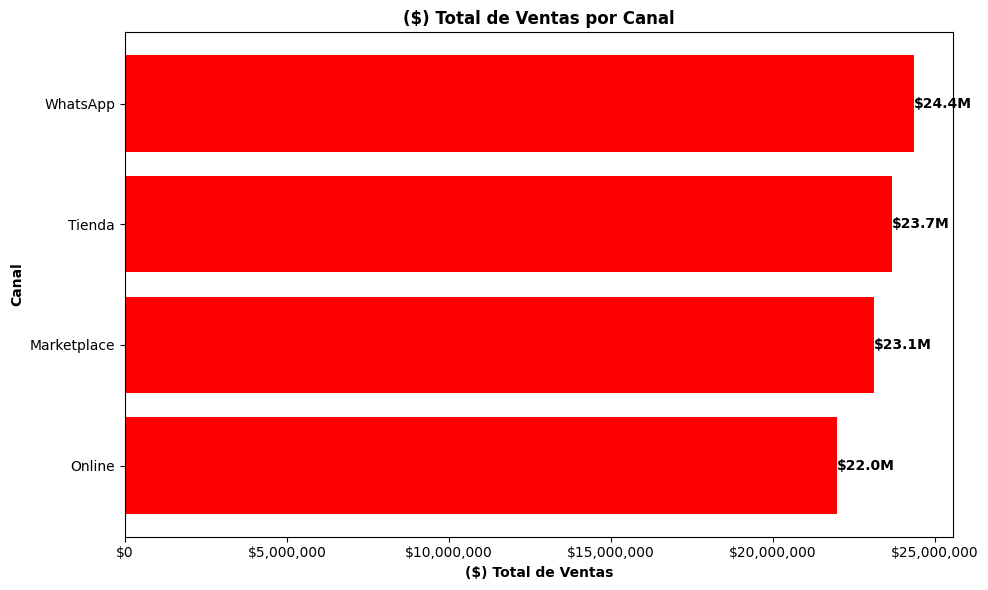

In [36]:
# Se crea ventas_canal y se agrupa por canal y se suma la cantidad total de ventas por canal y se ordenan
ventas_canal = df_viz.groupby("Canal")["Total_Venta"].sum().reset_index().sort_values("Total_Venta", ascending=True)

# Se crea el tamaño de la figura
plt.figure(figsize=(10, 6))

# Grafico de barras horizontal, eje y el canal, eje x el total de venta
plt.barh(ventas_canal["Canal"], ventas_canal["Total_Venta"], color="red")

# Evita que los valores del eje y se visualicen en notacion cientifica
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Titulos del grafico y etiquetas
plt.xlabel("($) Total de Ventas", fontweight="bold")
plt.ylabel("Canal", fontweight="bold")
plt.title("($) Total de Ventas por Canal", fontweight="bold")

plt.tight_layout() # Para que no se corten los textos

# Configuracion de las etiquetas de la barra
plt.bar_label(
    plt.gca().containers[0],
    labels=[f"${x/1_000_000:.1f}M" for x in ventas_canal["Total_Venta"]], # Formato del valor
    fontweight="bold" # Valores en negrita
    )
plt.show()

### Grafico 2 - Ventas por Categoria

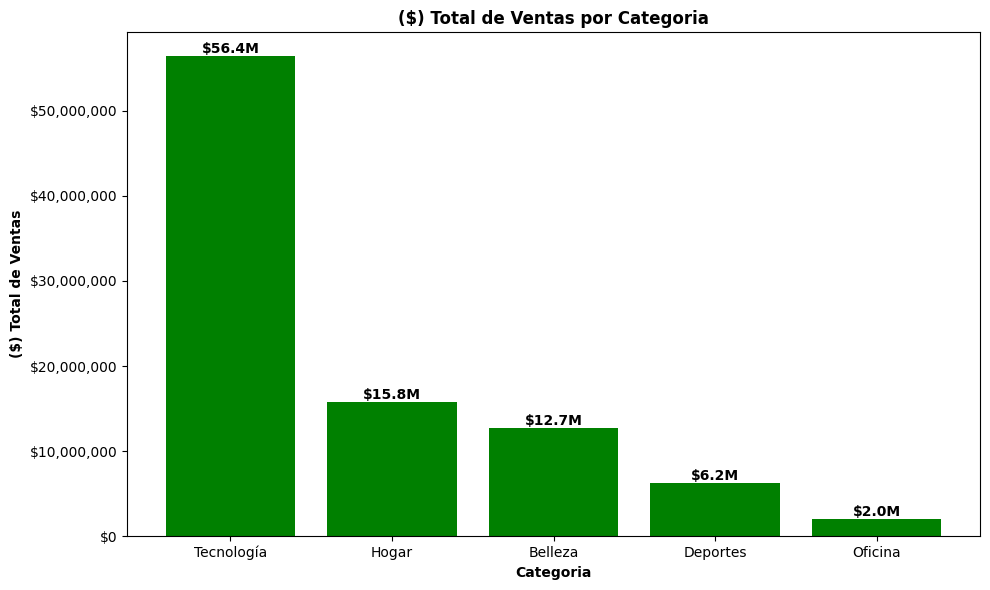

In [37]:
# Se crea ventas_categoria y se agrupa por categoria sumando el total de ventas
ventas_categoria = df_viz.groupby("Categoría")["Total_Venta"].sum().reset_index().sort_values("Total_Venta", ascending=False)

# Se crea el tamaño de la figura
plt.figure(figsize=(10, 6))

# Grafico de barras, eje x la categoria, eje y el total de venta
plt.bar(ventas_categoria["Categoría"], ventas_categoria["Total_Venta"], color="green")

# Evita que los valores del eje y se visualicen en notacion cientifica
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Titulos del grafico y etiquetas
plt.xlabel("Categoria", fontweight="bold")
plt.ylabel("($) Total de Ventas", fontweight="bold")
plt.title("($) Total de Ventas por Categoria", fontweight="bold")

plt.tight_layout() # Para que no se corten los textos

# Configuracion de las etiquetas de la barra
plt.bar_label(
    plt.gca().containers[0],
    labels=[f"${x/1_000_000:.1f}M" for x in ventas_categoria["Total_Venta"]], # Formato del valor
    fontweight="bold" # Valores en negrita
    )
plt.show()

### Grafico 3 - Ventas por Mes

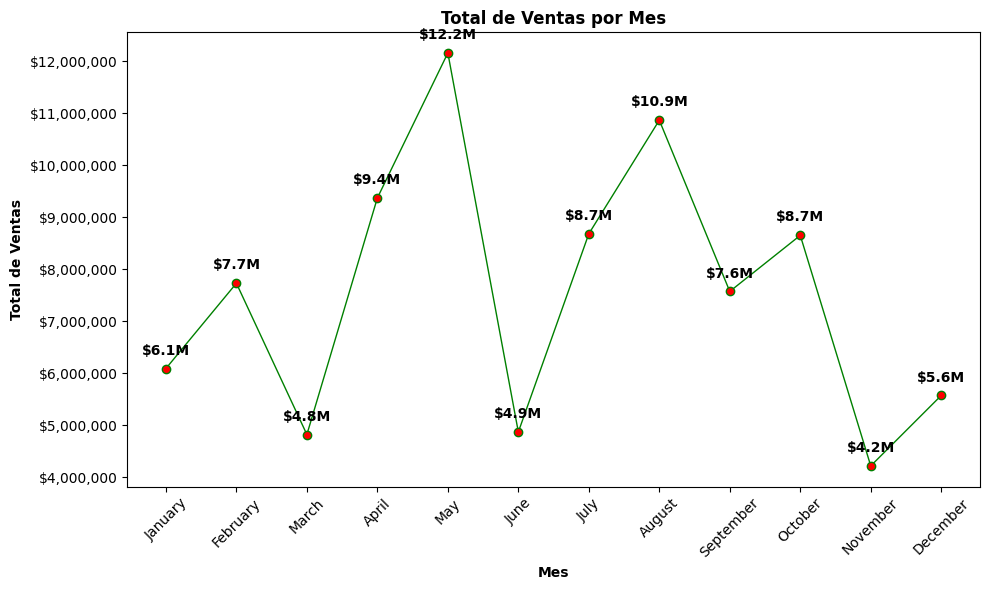

In [38]:
# Se crean dos columnas temporales para extraer el numero del mes y el nombre del mes
df_viz["Mes_Num"] = df_viz["Fecha"].dt.month
df_viz["Mes_Nombre"] = df_viz["Fecha"].dt.month_name()

# Se crea ventas_mes y se agrupa por Mes_Num y Mes_nombre sumando el total de ventas
ventas_mes = df_viz.groupby(["Mes_Num", "Mes_Nombre"])["Total_Venta"].sum().reset_index().sort_values("Mes_Num")

# Se crea el tamaño de la figura
plt.figure(figsize=(10, 6))

# Grafico de lineas, eje x el mes, eje y el total de venta
plt.plot(ventas_mes["Mes_Nombre"], ventas_mes["Total_Venta"], color="green", marker="o", linewidth=1, markerfacecolor="red")

# Evita que los valores del eje y se visualicen en notacion cientifica
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Titulos del grafico y etiquetas
plt.xlabel("Mes", fontweight="bold")
plt.ylabel("Total de Ventas", fontweight="bold")
plt.title("Total de Ventas por Mes", fontweight="bold")
plt.xticks(rotation=45) # Rotacion de las etiquetas del eje x

# Configuracion de las etiquetas para mostrar los valores de cada punto
for x, y in zip(ventas_mes["Mes_Nombre"], ventas_mes["Total_Venta"]):
  plt.annotate(
      f"${y/1_000_000:.1f}M", # Texto de la etiqueta
      (x, y), # Coordenadas de los puntos
      textcoords="offset points", # Desplaza la etiqueta en pixeles relativos al punto
      xytext=(0, 10), # Desplaza 10 pixeles hacia arriba para no tapar el punto
      ha="center", # Central el texto horizontalmente sobre el punto
      fontweight="bold"
  )

plt.tight_layout() # Para que no se corten los textos

plt.show()

### Grafico 4 - Top 10 Productos

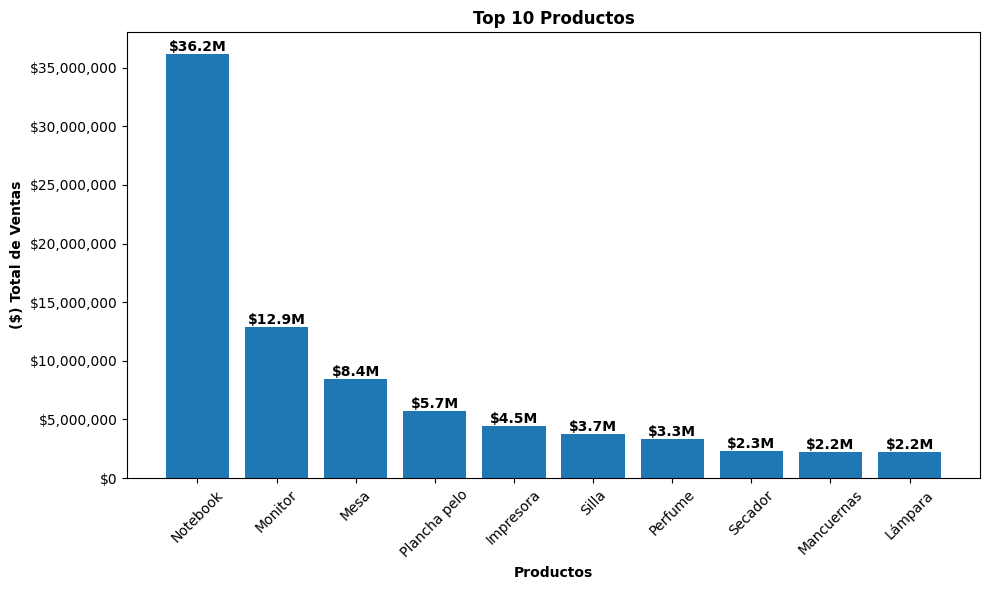

In [39]:
top_10_productos = df_viz.groupby("Producto")["Total_Venta"].sum().reset_index().sort_values("Total_Venta", ascending=False).head(10)

# Se crea el tamaño de la figura
plt.figure(figsize=(10, 6))

# Grafico de barras, eje x el mes, eje y el total de venta
plt.bar(top_10_productos["Producto"], top_10_productos["Total_Venta"])

# Evita que los valores del eje y se visualicen en notacion cientifica
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Titulos del grafico y etiquetas
plt.xlabel("Productos", fontweight="bold")
plt.ylabel("($) Total de Ventas", fontweight="bold")
plt.title("Top 10 Productos", fontweight="bold")
plt.xticks(rotation=45) # Rotacion de las etiquetas del eje x

plt.tight_layout() # Para que no se corten los textos

# Configuracion de las etiquetas de la barra
plt.bar_label(
    plt.gca().containers[0],
    labels=[f"${x/1_000_000:.1f}M" for x in top_10_productos["Total_Venta"]], # Formato del valor
    fontweight="bold" # Valores en negrita
    )
plt.show()